In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # type: ignore

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
import seaborn as sns

df = sns.load_dataset('mpg')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [9]:
print(df.shape)

(398, 9)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [11]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [12]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [13]:
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

In [15]:
df = pd.get_dummies(
    df,
    columns=['origin'],
    drop_first=True
)

In [16]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,name,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,chevrolet chevelle malibu,False,True
1,15.0,8,350.0,165.0,3693,11.5,70,buick skylark 320,False,True
2,18.0,8,318.0,150.0,3436,11.0,70,plymouth satellite,False,True
3,16.0,8,304.0,150.0,3433,12.0,70,amc rebel sst,False,True
4,17.0,8,302.0,140.0,3449,10.5,70,ford torino,False,True


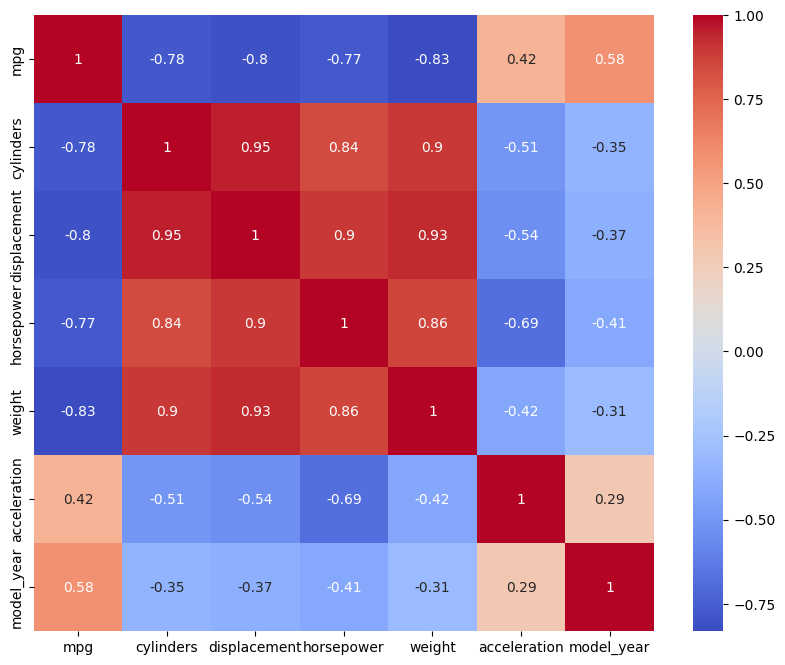

In [18]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

In [19]:
y = df['mpg']

In [20]:
X = df.drop('mpg', axis=1)

In [21]:
print(X.shape)
print(y.shape)

(398, 9)
(398,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
print(df.columns)

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'name', 'origin_japan', 'origin_usa'],
      dtype='object')


In [25]:
df.drop('name', axis=1, inplace=True)

In [27]:
X = df.drop('mpg', axis=1)
y = df['mpg']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [29]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
y_pred = lr.predict(X_test)

In [31]:
print(y_pred[:10])

[32.48505738 29.19696247 21.24501516 16.82601452 12.34342503 26.57958276
 27.56230198 10.06211821 16.63600146 21.7582273 ]


In [32]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 2.288158726714099
MSE : 8.338657478621627
RMSE : 2.8876733677169284
R2 Score : 0.8449096332762082


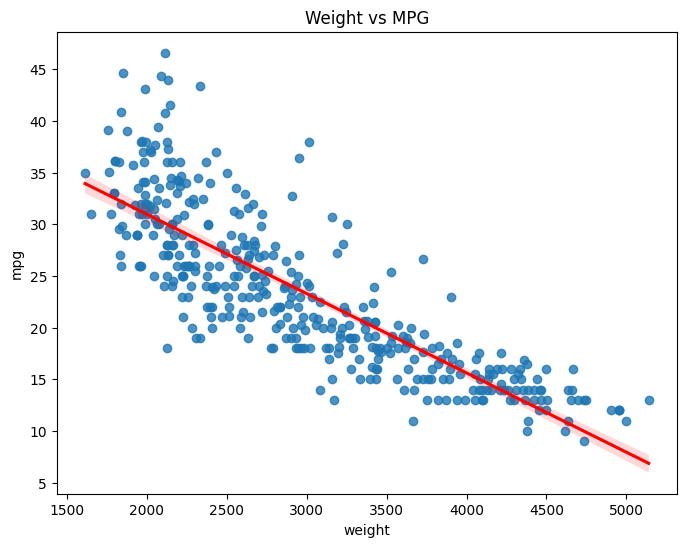

In [33]:
plt.figure(figsize=(8,6))

sns.regplot(
    x=df['weight'],
    y=df['mpg'],
    line_kws={'color':'red'}
)

plt.title("Weight vs MPG")
plt.show()

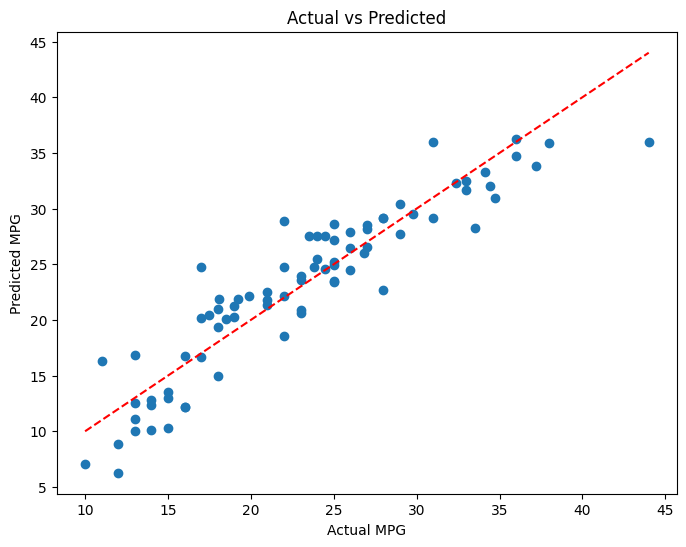

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")

plt.title("Actual vs Predicted")

plt.show()

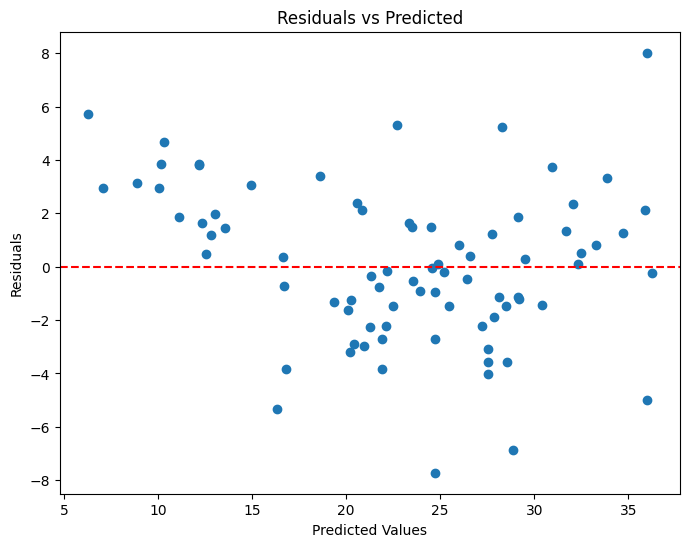

In [35]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs Predicted")

plt.show()

About all of  this 

Insights from Linear Regression on Auto MPG Dataset

--Weight has a strong negative correlation with MPG. As the weight of a vehicle increases, its fuel efficiency decreases.

--Horsepower and displacement are also negatively correlated with MPG. Vehicles with larger engines and higher horsepower tend to consume more fuel

--Model year shows a positive correlation with MPG. Newer vehicles generally have better fuel efficiency due to improvements in automotive technology.

--The correlation heatmap indicates that weight, displacement, and horsepower are among the most influential features affecting MPG.

--The scatter plot with the best-fit line confirms a clear linear relationship between vehicle weight and MPG.
The Actual vs Predicted plot shows that most predicted values are close to the actual MPG values, indicating that the Linear Regression model performs reasonably well.

--The Residuals vs Predicted Values plot shows that residuals are distributed around zero without a strong pattern, suggesting that the model captures the relationship fairly well.

--The R² score indicates that the model explains a significant portion of the variance in MPG. A higher R² value means better predictive performance.

--Overall, vehicle weight, engine size, and horsepower are the most important factors influencing fuel efficiency in the Auto MPG dataset.

--Linear Regression is effective for this dataset because many of the predictor variables exhibit a linear relationship with MPG.